# Análisis completo: predictores de violencia física en la adultez joven

**Fuente de datos:** ICPSR 34562 — Encuesta Nacional Longitudinal de la Juventud de 1997 (NLSY97)  
**Pregunta central:** ¿Qué información medida durante la adolescencia (14–17 años) ayuda a predecir la agresión física entre los 18 y los 23 años?  

Este notebook recorre el análisis de principio a fin:
1. Carga y limpieza de los datos originales
2. Construcción de targets y variables de conducta temprana
3. Exploración descriptiva
4. Análisis exploratorio sobre agresión de toda la vida
5. Modelo 1 — Global (muestra completa, predictores 14–17)
6. Modelo 2 — Inicio (personas sin agresión temprana)
7. Modelo 3 — Persistencia (personas con agresión temprana)
8. Comparación de los tres modelos del paper

In [1]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_palette("muted")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

BASE = Path("/home/cord2108/ITAM/Semestre_9/proyecto_final_polpub")
DS1_PATH = BASE / "data/ICPSR_34562/DS0001/34562-0001-Data.dta"
DS2_PATH = BASE / "data/ICPSR_34562/DS0002/34562-0002-Data.dta"

EARLY = range(14, 18)   # adolescencia: 14, 15, 16, 17
LATE  = range(18, 24)   # adultez temprana: 18, 19, 20, 21, 22, 23
AGES  = range(14, 26)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Carga y limpieza de datos

La NLSY97 guarda dos archivos `.dta` principales:
- **DS0001:** datos base para los 8,984 participantes (variables de 1997 + seguimiento por edad)
- **DS0002:** subconjunto con variables de edades 24–25

Un detalle importante: los valores faltantes en el NLSY97 están codificados como **números negativos** (−1 = no responde, −2 = no aplica, −3 = inaplicable, −4 = entrevista no realizada, −5 = missing por diseño). Hay que convertirlos todos a `NaN` antes de cualquier análisis.

In [2]:
def clean_nlsy(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte todos los códigos de missing del NLSY97 (valores negativos) a NaN."""
    df = df.copy()
    num = df.select_dtypes(include="number").columns
    df[num] = df[num].where(df[num] >= 0, np.nan)
    return df

print("Cargando DS0001...")
ds1 = clean_nlsy(pd.read_stata(DS1_PATH, convert_categoricals=False))

print("Cargando DS0002...")
ds2 = clean_nlsy(pd.read_stata(DS2_PATH, convert_categoricals=False))

# Unir agresión a los 24-25 desde DS0002
df = ds1.merge(ds2[["PUBID", "ASSAULT_CY24", "ASSAULT_CY25"]], on="PUBID", how="left")

print(f"\nDS0001: {ds1.shape[0]:,} filas × {ds1.shape[1]:,} columnas")
print(f"Dataset final (con edades 24-25): {df.shape[0]:,} filas × {df.shape[1]:,} columnas")

Cargando DS0001...
Cargando DS0002...

DS0001: 8,984 filas × 392 columnas
Dataset final (con edades 24-25): 8,984 filas × 394 columnas


In [3]:
# Funciones auxiliares para construir variables

def ecols(prefix, ages, source=df):
    """Lista de columnas '{prefix}{edad}' que existen en el DataFrame."""
    return [f"{prefix}{a}" for a in ages if f"{prefix}{a}" in source.columns]

def ever(d, cols):
    """1 si la conducta ocurrió en algún año de la ventana; NaN si ningún año fue observado."""
    sub = d[cols]
    out = (sub.max(axis=1) > 0).astype(float)
    out[sub.notna().sum(axis=1) == 0] = np.nan
    return out

def safe_sum(d, cols):
    """Suma por fila ignorando NaN; NaN si todos son NaN."""
    return d[cols].sum(axis=1, min_count=1)

def mean_pos(d, cols):
    """Promedio de valores no negativos (para ingresos)."""
    return d[cols].clip(lower=0).mean(axis=1)

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


---
## 2. Construcción de targets y variables

### Targets (variables dependientes)

| Variable | Definición |
|---|---|
| `EVER_ASSAULT` | 1 si reportó ≥1 agresión **en cualquier año** (14–25) |
| `ASSAULT_18_23` | 1 si reportó ≥1 agresión **entre los 18 y 23 años** ← target de los modelos del paper |
| `EARLY_ASSAULT` | 1 si reportó ≥1 agresión **entre los 14 y 17 años** (usado para dividir muestras) |

### Por qué usar ASSAULT_18_23 y no EVER_ASSAULT
Los datos de los 24–25 años provienen de una submuestra de personas en prisión, lo que inflaría artificialmente la prevalencia de agresión. Usar solo los 18–23 evita ese sesgo de selección y mantiene una ventana limpia donde los predictores son genuinamente previos al resultado.

In [4]:
assault_all = ecols("ASSAULT_CY", AGES)
assault_late = ecols("ASSAULT_CY", LATE)
assault_early = ecols("ASSAULT_CY", EARLY)

# Target de por vida (para análisis exploratorio)
df["TOTAL_ASSAULTS"] = safe_sum(df, assault_all)
df["EVER_ASSAULT"]   = (df["TOTAL_ASSAULTS"] > 0).astype(float)
df.loc[df["TOTAL_ASSAULTS"].isna(), "EVER_ASSAULT"] = np.nan

# Target del paper: agresión a los 18-23
df["ASSAULT_18_23"] = ever(df, assault_late)

# Variable de división de muestras: agresión a los 14-17
df["EARLY_ASSAULT"] = ever(df, assault_early)

print("=== Prevalencias ===")
print(f"EVER_ASSAULT    (14-25): {df['EVER_ASSAULT'].mean()*100:.1f}% "
      f"(n={df['EVER_ASSAULT'].notna().sum():,})")
print(f"ASSAULT_18_23   (18-23): {df['ASSAULT_18_23'].mean()*100:.1f}% "
      f"(n={df['ASSAULT_18_23'].notna().sum():,})")
print(f"EARLY_ASSAULT   (14-17): {df['EARLY_ASSAULT'].mean()*100:.1f}% "
      f"(n={df['EARLY_ASSAULT'].notna().sum():,})")

=== Prevalencias ===
EVER_ASSAULT    (14-25): 31.5% (n=8,958)
ASSAULT_18_23   (18-23): 16.9% (n=8,609)
EARLY_ASSAULT   (14-17): 23.3% (n=8,945)


---
## 3. Exploración descriptiva

Antes de modelar, conviene entender cómo se ve el patrón de agresión en los datos. La curva edad-crimen es uno de los hallazgos más consistentes en criminología: la conducta antisocial aumenta en la adolescencia media y decrece en la adultez.

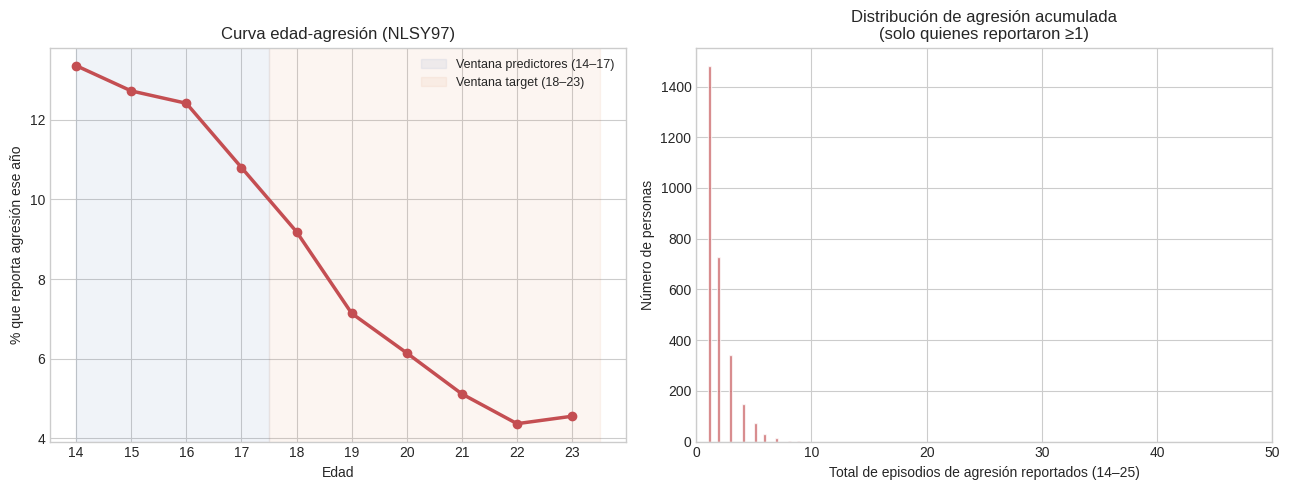

Obs por edad: mín=1,383  máx=8,399


In [5]:
# Curva edad-agresión
ages_plot = range(14, 24)
prevalencia = []
ns_por_edad = []

for a in ages_plot:
    col = f"ASSAULT_CY{a}"
    if col in ds1.columns:
        s = ds1[col].dropna()
        prevalencia.append((s > 0).mean() * 100)
        ns_por_edad.append(len(s))
    else:
        prevalencia.append(np.nan)
        ns_por_edad.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Curva prevalencia
ax1.plot(list(ages_plot), prevalencia, marker="o", color="#c44e52", linewidth=2.5)
ax1.axvspan(14, 17.5, alpha=0.08, color="#4c72b0", label="Ventana predictores (14–17)")
ax1.axvspan(17.5, 23.5, alpha=0.08, color="#dd8452", label="Ventana target (18–23)")
ax1.set_xlabel("Edad")
ax1.set_ylabel("% que reporta agresión ese año")
ax1.set_title("Curva edad-agresión (NLSY97)")
ax1.set_xticks(list(ages_plot))
ax1.legend(fontsize=9)

# Distribución de agresión total de por vida
total_valid = df["TOTAL_ASSAULTS"].dropna()
ax2.hist(total_valid[total_valid > 0], bins=30, color="#c44e52", alpha=0.75, edgecolor="white")
ax2.set_xlabel("Total de episodios de agresión reportados (14–25)")
ax2.set_ylabel("Número de personas")
ax2.set_title("Distribución de agresión acumulada\n(solo quienes reportaron ≥1)")
ax2.set_xlim(0, 50)

fig.tight_layout()
plt.show()
print(f"Obs por edad: mín={min(ns_por_edad):,}  máx={max(ns_por_edad):,}")

In [29]:
# Tabla de números detrás de la curva edad-agresión
rows = []
for a in range(14, 24):
    col = f"ASSAULT_CY{a}"
    if col in ds1.columns:
        s = ds1[col].dropna()
        rows.append({
            "Edad": a,
            "n observados": len(s),
            "n con agresión": int((s > 0).sum()),
            "prevalencia (%)": round((s > 0).mean() * 100, 2),
        })

tabla_edad = pd.DataFrame(rows).set_index("Edad")
display(tabla_edad)


,n observados,n con agresión,prevalencia (%)
Edad,,,
14,3489,466,13.36
15,5188,660,12.72
16,6921,859,12.41
17,8399,907,10.80
18,8122,746,9.18
19,7901,564,7.14
20,6219,382,6.14
21,4575,234,5.11
22,2976,130,4.37


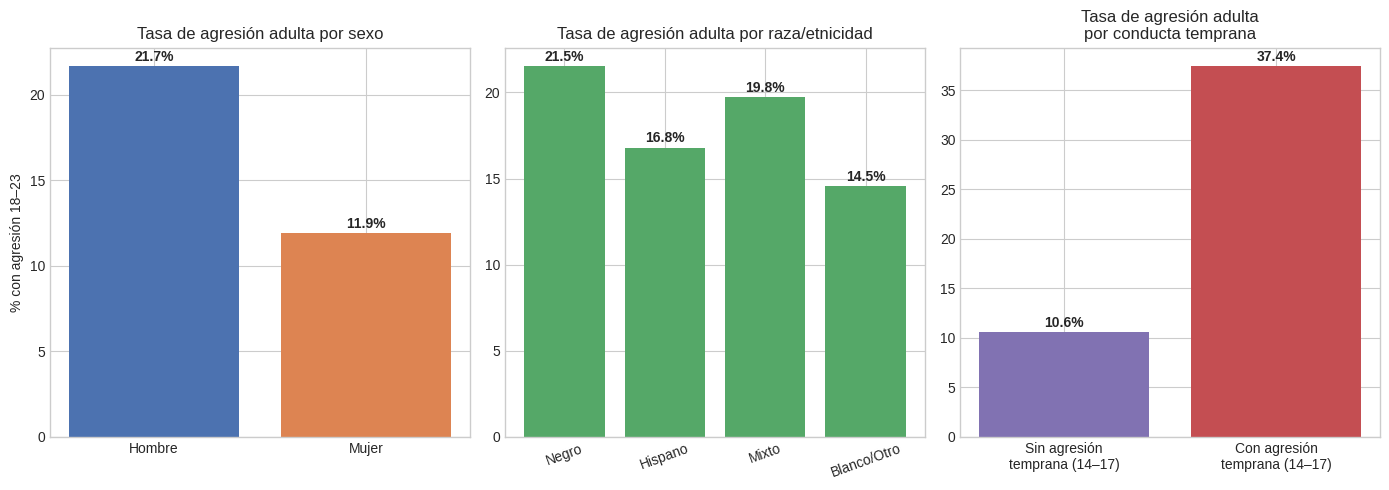

La diferencia en el tercer panel (10.6% vs 37.4%) es la señal más fuerte de todo el análisis.


In [6]:
# Contrastes bivariados simples sobre ASSAULT_18_23
dfa = df[df["ASSAULT_18_23"].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Por sexo
tasa_sexo = dfa.groupby("SEX")["ASSAULT_18_23"].mean() * 100
tasa_sexo.index = ["Hombre", "Mujer"]
axes[0].bar(tasa_sexo.index, tasa_sexo.values, color=["#4c72b0", "#dd8452"])
axes[0].set_title("Tasa de agresión adulta por sexo")
axes[0].set_ylabel("% con agresión 18–23")
for i, v in enumerate(tasa_sexo.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# Por raza/etnicidad
tasa_raza = dfa.groupby("RACE_ETHNICITY")["ASSAULT_18_23"].mean() * 100
tasa_raza.index = ["Negro", "Hispano", "Mixto", "Blanco/Otro"]
axes[1].bar(tasa_raza.index, tasa_raza.values, color="#55a868")
axes[1].set_title("Tasa de agresión adulta por raza/etnicidad")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(tasa_raza.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# Por agresión temprana
tasa_early = dfa.groupby("EARLY_ASSAULT")["ASSAULT_18_23"].mean() * 100
tasa_early.index = ["Sin agresión\ntemprana (14–17)", "Con agresión\ntemprana (14–17)"]
axes[2].bar(tasa_early.index, tasa_early.values, color=["#8172b2", "#c44e52"])
axes[2].set_title("Tasa de agresión adulta\npor conducta temprana")
for i, v in enumerate(tasa_early.values):
    axes[2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

fig.tight_layout()
plt.show()
print("La diferencia en el tercer panel (10.6% vs 37.4%) es la señal más fuerte de todo el análisis.")

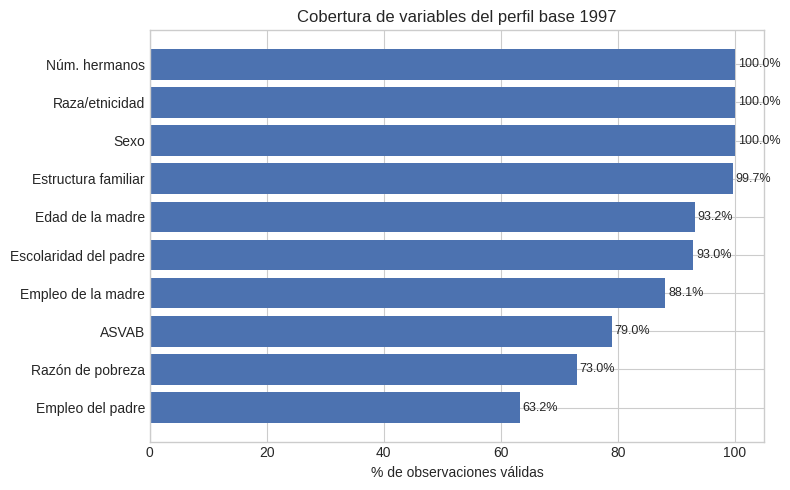

In [7]:
# Cobertura (% de observaciones válidas) de las principales variables
vars_cobertura = {
    "SEX": "Sexo",
    "RACE_ETHNICITY": "Raza/etnicidad",
    "NUMSIBS": "Núm. hermanos",
    "ASVAB_SCORE": "ASVAB",
    "POVRATIO97": "Razón de pobreza",
    "BIOMOMAGE": "Edad de la madre",
    "FMSTRC97": "Estructura familiar",
    "RESPARED": "Escolaridad del padre",
    "MOMEMP97": "Empleo de la madre",
    "DADEMP97": "Empleo del padre",
}
cob = pd.Series(
    {label: ds1[col].notna().mean() * 100 for col, label in vars_cobertura.items()}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cob.index, cob.values, color="#4c72b0")
ax.set_xlabel("% de observaciones válidas")
ax.set_title("Cobertura de variables del perfil base 1997")
ax.set_xlim(0, 105)
for i, v in enumerate(cob.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Análisis exploratorio: EVER_ASSAULT (toda la vida)

Antes de definir el diseño predictivo final, corrimos un análisis sobre el target de por vida (`EVER_ASSAULT`). Este modelo usa **totales acumulados** de todas las conductas (14–25 años), incluyendo variables contemporáneas al target como el número total de arrestos. Por eso **no es un diseño predictivo limpio** — es una exploración de qué tan bien se puede predecir la agresión cuando se tiene toda la información disponible.

> **Prevalencia:** 31.46% (vs 16.9% del target del paper). La diferencia se debe a que este target captura agresión en cualquier año de la vida, incluyendo la adolescencia.

In [8]:
# Construir features de por vida (totales acumulados)
has_obs = df[assault_all].notna().any(axis=1)
dfa_exp = df[has_obs].copy()

agg = pd.DataFrame(index=dfa_exp.index)
agg["TOTAL_DESTROY"]    = safe_sum(dfa_exp, ecols("DESTROY_CY", AGES))
agg["TOTAL_STEAL_LO"]   = safe_sum(dfa_exp, ecols("STEAL_UNDER_50_CY", AGES))
agg["TOTAL_STEAL_HI"]   = safe_sum(dfa_exp, ecols("STEAL_OVER_50_CY", AGES))
agg["TOTAL_SELL_DRUGS"] = safe_sum(dfa_exp, ecols("SELL_DRUGS_CY", AGES))
agg["TOTAL_CARR_GUN"]   = safe_sum(dfa_exp, ecols("CARR_GUN_CY", AGES))
agg["TOTAL_GANG"]       = safe_sum(dfa_exp, ecols("GANGS_CY", AGES))
agg["TOTAL_ALCOHOL"]    = safe_sum(dfa_exp, ecols("ALCOHOL_CY", AGES))
agg["TOTAL_MARIJUANA"]  = safe_sum(dfa_exp, ecols("MARIJUANA_CY", AGES))
agg["TOTAL_HARD_DRUGS"] = safe_sum(dfa_exp, ecols("HARD_DRUGS_CY", AGES))
agg["TOTAL_SMOKING"]    = safe_sum(dfa_exp, ecols("SMOKING_CY", AGES))
agg["TOTAL_ARRESTS"]    = dfa_exp["TOTARRESTS"]
agg["AGE_FIRST_ARREST"] = dfa_exp["FIRSTARREST"]
agg["TOTAL_INCARC"]     = dfa_exp["TOTINCARC"]
agg["AVG_HHINC"]        = mean_pos(dfa_exp, ecols("HHINC_CY", AGES))
agg["AVG_RINC"]         = mean_pos(dfa_exp, ecols("RINC_CY", AGES))
agg["ASVAB_SCORE"]      = dfa_exp["ASVAB_SCORE"]
agg["POVRATIO97"]       = dfa_exp["POVRATIO97"]
agg["NUMSIBS"]          = dfa_exp["NUMSIBS"]
agg["BIOMOMAGE"]        = dfa_exp["BIOMOMAGE"]
agg["SEX"]              = dfa_exp["SEX"]
agg["RACE_ETHNICITY"]   = dfa_exp["RACE_ETHNICITY"]
agg["FMSTRC97"]         = dfa_exp["FMSTRC97"]
agg["RESPARED"]         = dfa_exp["RESPARED"]
agg["MOMEMP97"]         = dfa_exp["MOMEMP97"]
agg["DADEMP97"]         = dfa_exp["DADEMP97"]

feat_exp = list(agg.columns)
y_exp = dfa_exp["EVER_ASSAULT"]
mask_exp = y_exp.notna()
X_exp_raw = agg[mask_exp]
y_exp = y_exp[mask_exp].astype(int)

imp_exp = SimpleImputer(strategy="median")
X_exp = pd.DataFrame(imp_exp.fit_transform(X_exp_raw), columns=feat_exp, index=X_exp_raw.index)

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

print(f"Muestra: {len(y_exp):,} | Train: {len(y_tr_e):,} | Test: {len(y_te_e):,}")
print(f"Prevalencia EVER_ASSAULT: {y_exp.mean()*100:.1f}%")

Muestra: 8,958 | Train: 7,166 | Test: 1,792
Prevalencia EVER_ASSAULT: 31.5%


In [9]:
rf_exp = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=15,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
)
rf_exp.fit(X_tr_e, y_tr_e)

auc_exp  = roc_auc_score(y_te_e, rf_exp.predict_proba(X_te_e)[:, 1])
cv_exp   = cross_val_score(rf_exp, X_exp, y_exp, cv=5, scoring="roc_auc", n_jobs=-1)
gini_exp = pd.Series(rf_exp.feature_importances_, index=feat_exp).sort_values(ascending=False)

print(f"AUC test : {auc_exp:.4f}")
print(f"AUC CV   : {cv_exp.mean():.4f} ± {cv_exp.std():.4f}")

AUC test : 0.8135
AUC CV   : 0.8215 ± 0.0242


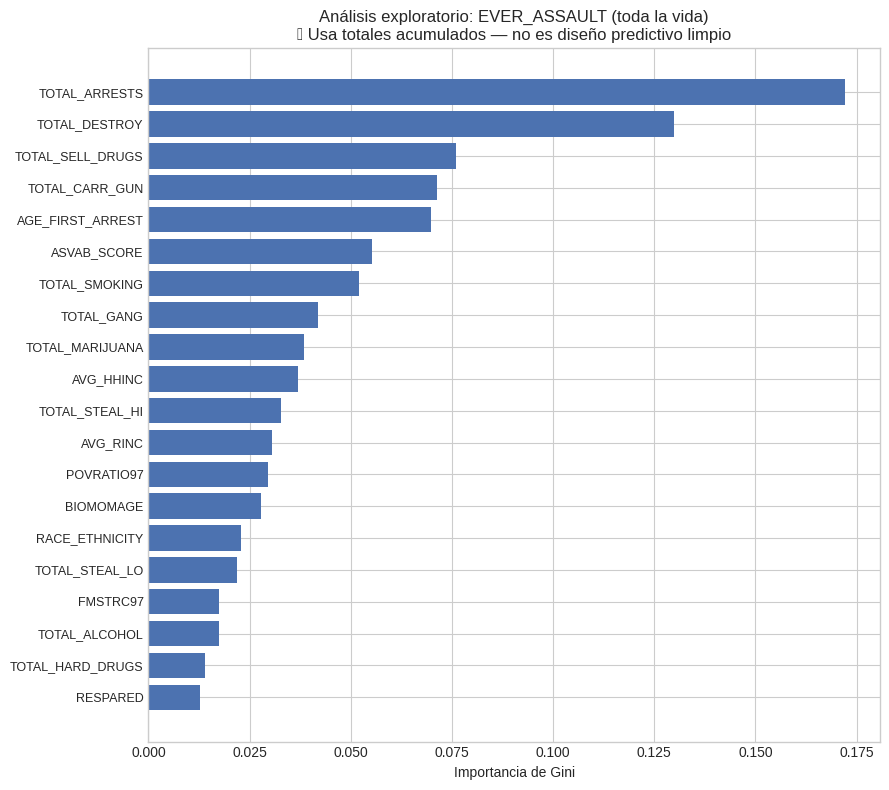

Top 5 variables:
  TOTAL_ARRESTS          0.1722
  TOTAL_DESTROY          0.1299
  TOTAL_SELL_DRUGS       0.0761
  TOTAL_CARR_GUN         0.0713
  AGE_FIRST_ARREST       0.0698


In [10]:
# Visualizar importancia Gini — exploratorio
fig, ax = plt.subplots(figsize=(9, 8))
g = gini_exp.head(20)[::-1]
ax.barh(range(len(g)), g.values, color="#4c72b0")
ax.set_yticks(range(len(g)))
ax.set_yticklabels(g.index, fontsize=9)
ax.set_xlabel("Importancia de Gini")
ax.set_title("Análisis exploratorio: EVER_ASSAULT (toda la vida)\n"
             "⚠ Usa totales acumulados — no es diseño predictivo limpio")
fig.tight_layout()
plt.show()

print("Top 5 variables:")
for k, v in gini_exp.head(5).items():
    print(f"  {k:22s} {v:.4f}")

---
## 5. Modelo 1 — Global (ASSAULT_18_23, muestra completa)

Este es el primer modelo del paper. El diseño temporal es limpio:
- **Predictores:** conducta y contexto medidos entre los 14 y 17 años + perfil base de 1997
- **Target:** agresión autorreportada entre los 18 y 23 años

No hay ningún predictor que use información posterior a los 17 años. Eso garantiza que estamos haciendo predicción genuina, no una asociación contemporánea.

**Prevalencia del target:** 16.9% — la muestra está desbalanceada (más negativos que positivos). Por eso usamos `class_weight="balanced"` en el Random Forest.

In [11]:
# Filtrar a personas con observación en la ventana 18-23
obs_late = ds1[ecols("ASSAULT_CY", LATE, ds1)].notna().any(axis=1)
ds = ds1[obs_late].copy()
ds["ASSAULT_18_23"] = ever(ds, ecols("ASSAULT_CY", LATE, ds))
ds = ds[ds["ASSAULT_18_23"].notna()].copy()

print(f"Personas con observación en 18-23: {len(ds):,}")
print(f"Prevalencia ASSAULT_18_23: {ds['ASSAULT_18_23'].mean()*100:.1f}%")
print(f"  Positivos (agresión): {ds['ASSAULT_18_23'].sum():.0f}")
print(f"  Negativos (sin agresión): {(ds['ASSAULT_18_23']==0).sum():,}")

Personas con observación en 18-23: 8,609
Prevalencia ASSAULT_18_23: 16.9%
  Positivos (agresión): 1455
  Negativos (sin agresión): 7,154


In [12]:
# Construir matriz de features (predictores 14-17 + perfil 1997)
X1 = pd.DataFrame(index=ds.index)

# Conducta delictiva temprana (ever 14-17)
X1["EARLY_ASSAULT"]    = ever(ds, ecols("ASSAULT_CY",      EARLY, ds))
X1["EARLY_DESTROY"]    = ever(ds, ecols("DESTROY_CY",      EARLY, ds))
X1["EARLY_STEAL_LO"]   = ever(ds, ecols("STEAL_UNDER_50_CY", EARLY, ds))
X1["EARLY_STEAL_HI"]   = ever(ds, ecols("STEAL_OVER_50_CY",  EARLY, ds))
X1["EARLY_SELL_DRUGS"] = ever(ds, ecols("SELL_DRUGS_CY",   EARLY, ds))
X1["EARLY_CARR_GUN"]   = ever(ds, ecols("CARR_GUN_CY",     EARLY, ds))
X1["EARLY_GANG"]       = ever(ds, ecols("GANGS_CY",        EARLY, ds))
# Sustancias
X1["EARLY_ALCOHOL"]    = ever(ds, ecols("ALCOHOL_CY",      EARLY, ds))
X1["EARLY_MARIJUANA"]  = ever(ds, ecols("MARIJUANA_CY",    EARLY, ds))
X1["EARLY_HARD_DRUGS"] = ever(ds, ecols("HARD_DRUGS_CY",   EARLY, ds))
X1["EARLY_SMOKING"]    = ever(ds, ecols("SMOKING_CY",      EARLY, ds))
# Contacto con la justicia (hasta los 17)
X1["ARR_BY17"]    = (ds["EVER_ARR_CY17"] > 0).astype(float)
X1["INCARC_BY17"] = (ds["EVER_INCARC_CY17"] > 0).astype(float)
# Económico temprano
X1["HHINC_EARLY"] = mean_pos(ds, ecols("HHINC_CY", EARLY, ds))
# Perfil base 1997 (estático)
X1["ASVAB_SCORE"]    = ds["ASVAB_SCORE"]
X1["POVRATIO97"]     = ds["POVRATIO97"]
X1["NUMSIBS"]        = ds["NUMSIBS"]
X1["BIOMOMAGE"]      = ds["BIOMOMAGE"]
X1["SEX"]            = ds["SEX"]
X1["RACE_ETHNICITY"] = ds["RACE_ETHNICITY"]
X1["FMSTRC97"]       = ds["FMSTRC97"]
X1["RESPARED"]       = ds["RESPARED"]
X1["MOMEMP97"]       = ds["MOMEMP97"]
X1["DADEMP97"]       = ds["DADEMP97"]

y1 = ds["ASSAULT_18_23"].astype(int)
feat1 = list(X1.columns)
print(f"Features: {len(feat1)} | Observaciones: {len(y1):,}")

Features: 24 | Observaciones: 8,609


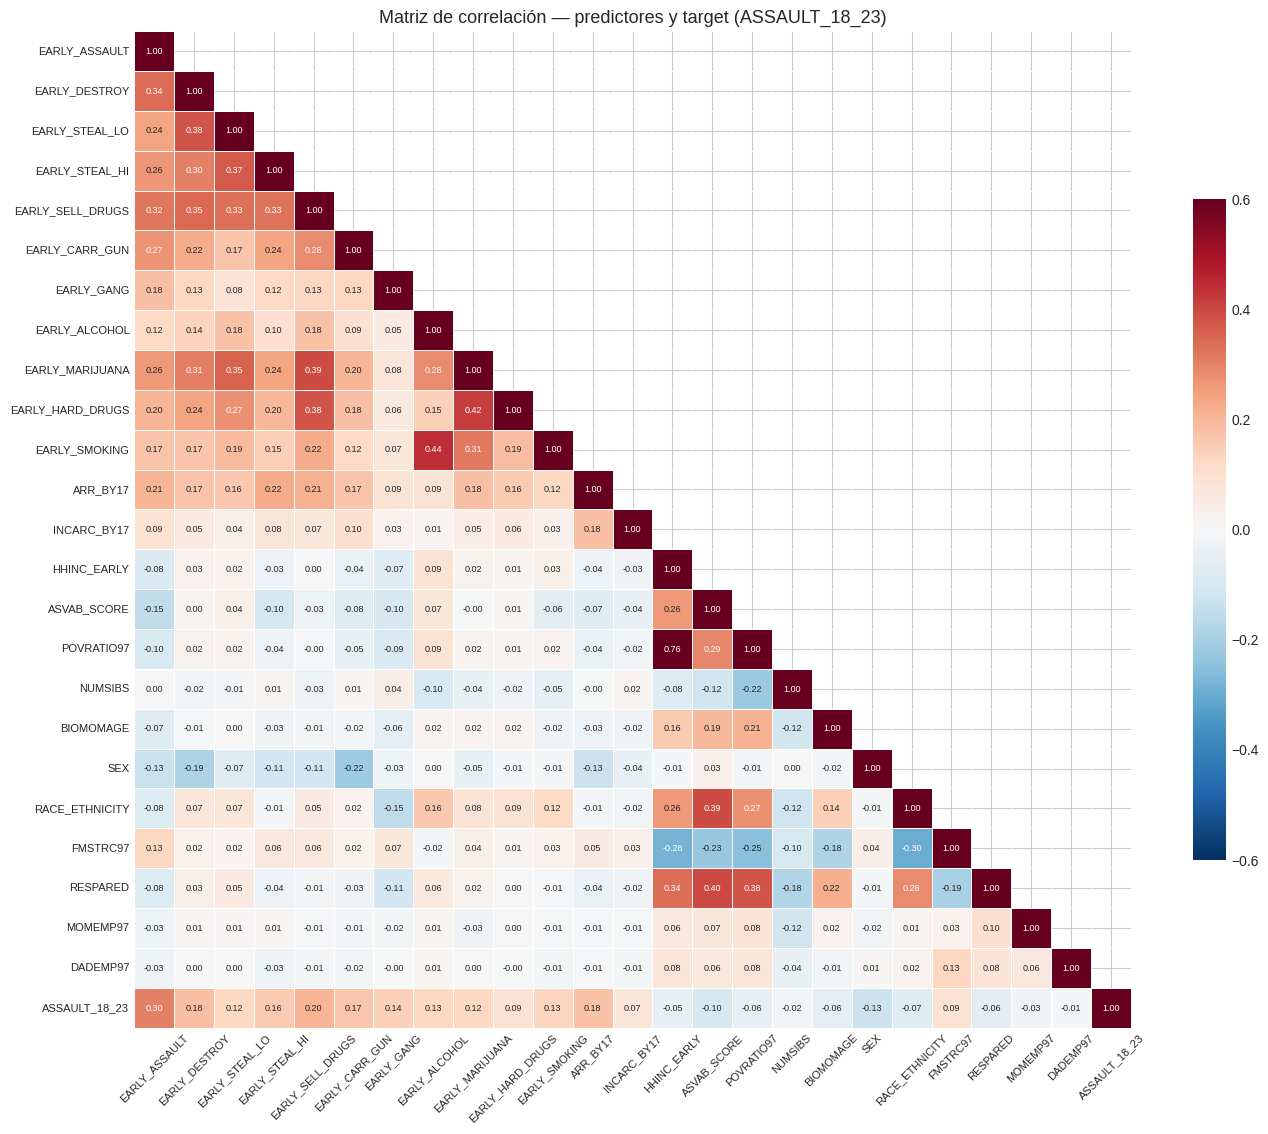


Correlación de cada predictor con ASSAULT_18_23:
  EARLY_ASSAULT           +0.304  ████████████
  EARLY_SELL_DRUGS        +0.203  ████████
  EARLY_DESTROY           +0.181  ███████
  ARR_BY17                +0.177  ███████
  EARLY_CARR_GUN          +0.167  ██████
  EARLY_STEAL_HI          +0.155  ██████
  EARLY_GANG              +0.141  █████
  EARLY_SMOKING           +0.134  █████
  SEX                     -0.130  █████
  EARLY_ALCOHOL           +0.126  █████
  EARLY_MARIJUANA         +0.124  ████
  EARLY_STEAL_LO          +0.123  ████
  ASVAB_SCORE             -0.103  ████
  EARLY_HARD_DRUGS        +0.090  ███
  FMSTRC97                +0.089  ███
  RACE_ETHNICITY          -0.074  ██
  INCARC_BY17             +0.070  ██
  RESPARED                -0.064  ██
  BIOMOMAGE               -0.060  ██
  POVRATIO97              -0.056  ██
  HHINC_EARLY             -0.054  ██
  MOMEMP97                -0.025  █
  NUMSIBS                 -0.020  
  DADEMP97                -0.011  


In [30]:
# Matriz de correlación de los predictores (Pearson, sobre valores imputados)
# Añadimos el target al final para ver su relación con cada predictor

X1_corr = X1i.copy()          # usa la versión ya imputada con medianas
X1_corr["ASSAULT_18_23"] = y1  # target al final

corr = X1_corr.corr()

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # oculta triángulo superior (redundante)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6.5},
    cmap="RdBu_r",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.4,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.6},
)

ax.set_title("Matriz de correlación — predictores y target (ASSAULT_18_23)", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
fig.tight_layout()
plt.show()

# Correlaciones con el target, ordenadas de mayor a menor (valor absoluto)
print("\nCorrelación de cada predictor con ASSAULT_18_23:")
corr_target = corr["ASSAULT_18_23"].drop("ASSAULT_18_23").sort_values(key=abs, ascending=False)
for var, r in corr_target.items():
    bar = "█" * int(abs(r) * 40)
    print(f"  {var:22s}  {r:+.3f}  {bar}")


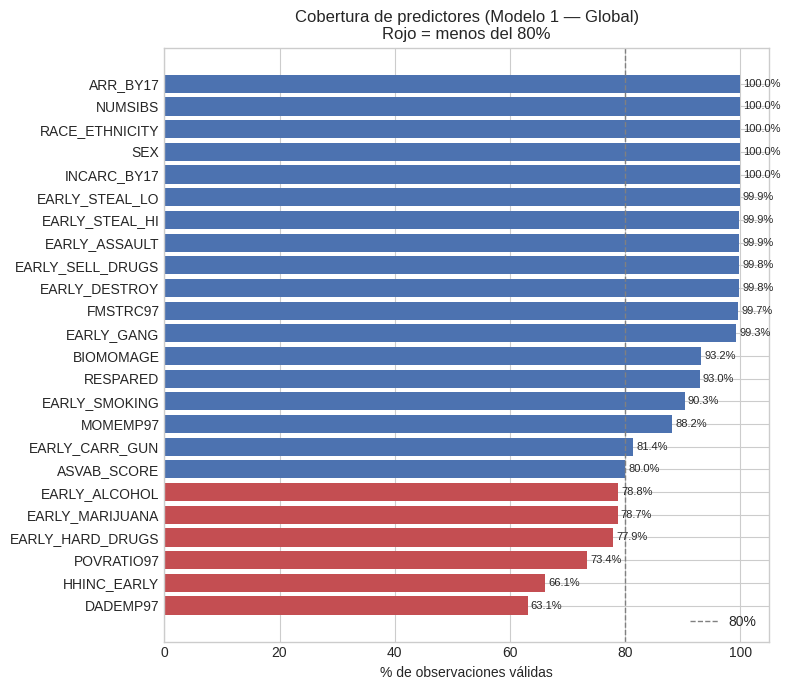

In [13]:
# Cobertura de predictores (% de valores no-NaN)
cob1 = X1.notna().mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#c44e52" if v < 80 else "#4c72b0" for v in cob1.values]
ax.barh(cob1.index, cob1.values, color=colors)
ax.axvline(80, color="gray", linestyle="--", linewidth=1, label="80%")
ax.set_xlabel("% de observaciones válidas")
ax.set_title("Cobertura de predictores (Modelo 1 — Global)\nRojo = menos del 80%")
ax.set_xlim(0, 105)
ax.legend()
for i, v in enumerate(cob1.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
fig.tight_layout()
plt.show()

In [14]:
# Imputar con mediana y hacer split 80/20
imp1 = SimpleImputer(strategy="median")
X1i = pd.DataFrame(imp1.fit_transform(X1), columns=feat1, index=X1.index)

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1i, y1, test_size=0.2, random_state=42, stratify=y1
)

print(f"Train: {len(X1_tr):,} | Test: {len(X1_te):,}")

Train: 6,887 | Test: 1,722


In [15]:
# Entrenar Random Forest — Modelo 1 Global
rf1 = RandomForestClassifier(
    n_estimators=400, max_depth=10, min_samples_leaf=20,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
)
rf1.fit(X1_tr, y1_tr)

y1_prob = rf1.predict_proba(X1_te)[:, 1]
y1_pred = rf1.predict(X1_te)

auc1 = roc_auc_score(y1_te, y1_prob)
cv1  = cross_val_score(rf1, X1i, y1, cv=5, scoring="roc_auc", n_jobs=-1)

print(f"AUC test : {auc1:.4f}")
print(f"AUC CV   : {cv1.mean():.4f} ± {cv1.std():.4f}")
print()
print(classification_report(y1_te, y1_pred, target_names=["Sin agresión", "Con agresión"]))

AUC test : 0.7987
AUC CV   : 0.7637 ± 0.0295

              precision    recall  f1-score   support

Sin agresión       0.92      0.78      0.84      1431
Con agresión       0.38      0.66      0.48       291

    accuracy                           0.76      1722
   macro avg       0.65      0.72      0.66      1722
weighted avg       0.83      0.76      0.78      1722



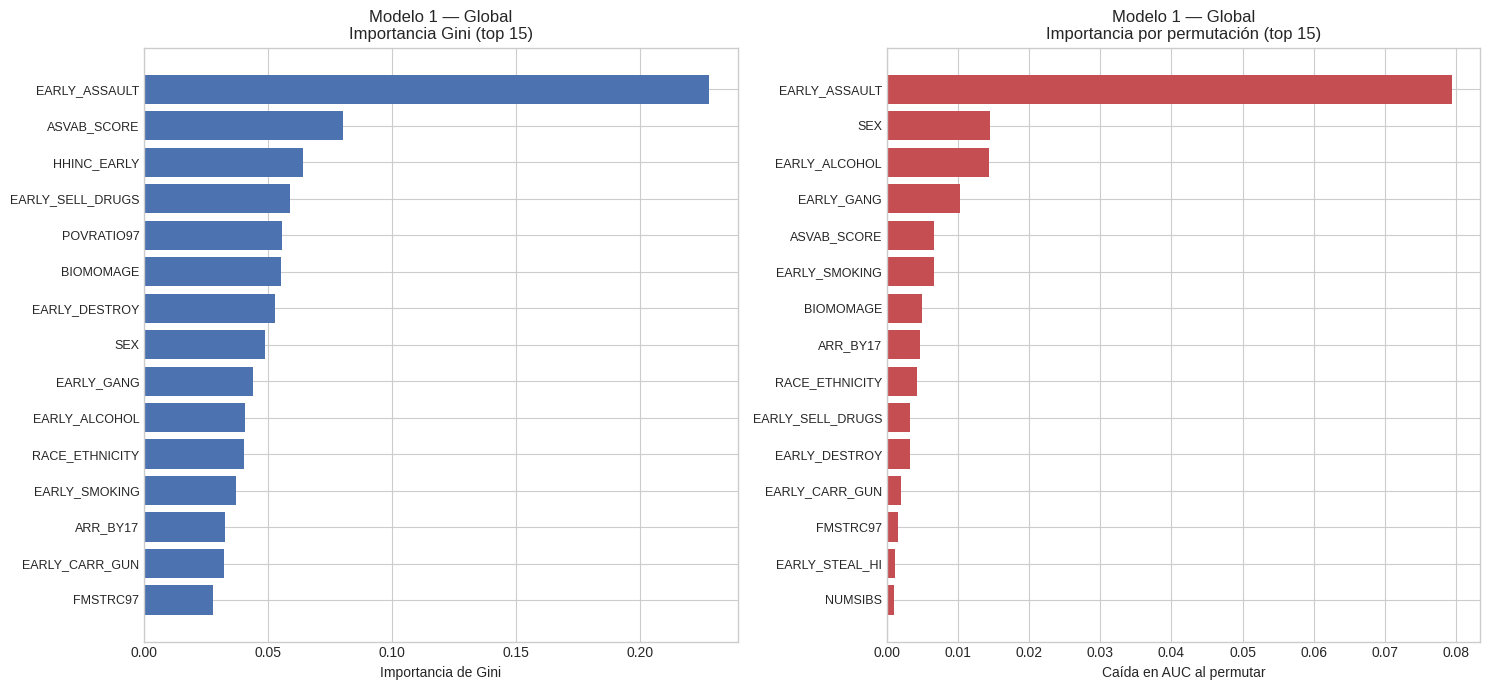

Variables robustas (top-10 en Gini Y en permutación):
  {'SEX', 'BIOMOMAGE', 'ASVAB_SCORE', 'EARLY_ASSAULT', 'EARLY_GANG', 'EARLY_ALCOHOL', 'EARLY_SELL_DRUGS'}


In [16]:
# Importancia Gini y permutación — Modelo 1
gini1 = pd.Series(rf1.feature_importances_, index=feat1).sort_values(ascending=False)

perm1 = permutation_importance(
    rf1, X1_te, y1_te, n_repeats=30, random_state=42, scoring="roc_auc", n_jobs=-1
)
perm1_s = pd.Series(perm1.importances_mean, index=feat1).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Gini
g = gini1.head(15)[::-1]
ax1.barh(range(len(g)), g.values, color="#4c72b0")
ax1.set_yticks(range(len(g)))
ax1.set_yticklabels(g.index, fontsize=9)
ax1.set_xlabel("Importancia de Gini")
ax1.set_title("Modelo 1 — Global\nImportancia Gini (top 15)")

# Permutación
p = perm1_s.head(15)[::-1]
ax2.barh(range(len(p)), p.values, color="#c44e52")
ax2.set_yticks(range(len(p)))
ax2.set_yticklabels(p.index, fontsize=9)
ax2.set_xlabel("Caída en AUC al permutar")
ax2.set_title("Modelo 1 — Global\nImportancia por permutación (top 15)")

fig.tight_layout()
plt.show()

# Señal: variables que aparecen en top-10 de ambas métricas
top_gini = set(gini1.head(10).index)
top_perm = set(perm1_s.head(10).index)
print("Variables robustas (top-10 en Gini Y en permutación):")
print(" ", top_gini & top_perm)

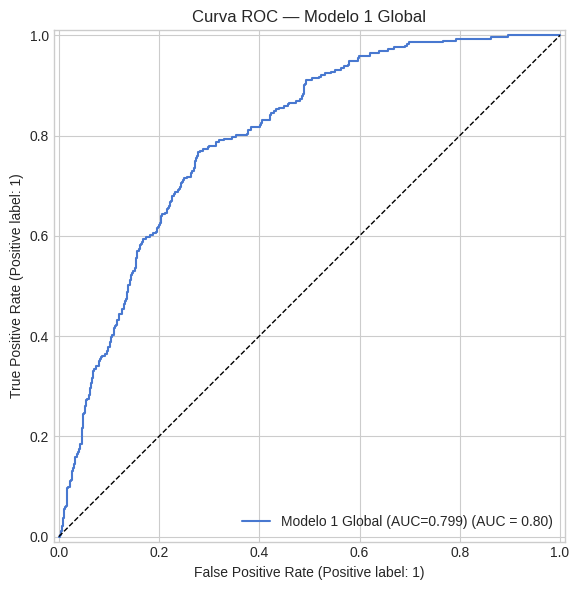

In [17]:
# Curva ROC — Modelo 1
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y1_te, y1_prob, ax=ax,
                                  name=f"Modelo 1 Global (AUC={auc1:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Modelo 1 Global")
plt.tight_layout()
plt.show()

---
## 6. PCA sobre los factores de riesgo (14–17)

El análisis de componentes principales (PCA) no lo usamos para predecir individualmente, sino para entender **la estructura latente** de las conductas adolescentes. La pregunta es: ¿hay una dimensión común detrás de todas estas conductas (consumo de drogas, robos, pandillas, agresión) o son fenómenos independientes?

Aplicamos PCA sobre las 18 variables continuas/ordinales del conjunto de predictores (excluyendo las categóricas nominales como raza y estructura familiar).

In [18]:
pca_vars = [
    "EARLY_ASSAULT", "EARLY_DESTROY", "EARLY_STEAL_LO", "EARLY_STEAL_HI",
    "EARLY_SELL_DRUGS", "EARLY_CARR_GUN", "EARLY_GANG", "EARLY_ALCOHOL",
    "EARLY_MARIJUANA", "EARLY_HARD_DRUGS", "EARLY_SMOKING", "ARR_BY17",
    "INCARC_BY17", "HHINC_EARLY", "ASVAB_SCORE", "POVRATIO97", "NUMSIBS", "BIOMOMAGE"
]

Xp = StandardScaler().fit_transform(X1i[pca_vars])
pca = PCA().fit(Xp)
evr = pca.explained_variance_ratio_
scores_pca = pca.transform(Xp)

print("Varianza explicada por componente:")
for i, v in enumerate(evr[:8]):
    print(f"  PC{i+1}: {v*100:.1f}%  (acumulado: {np.cumsum(evr)[i]*100:.1f}%)")

Varianza explicada por componente:
  PC1: 19.4%  (acumulado: 19.4%)
  PC2: 12.2%  (acumulado: 31.6%)
  PC3: 6.9%  (acumulado: 38.6%)
  PC4: 6.1%  (acumulado: 44.6%)
  PC5: 5.7%  (acumulado: 50.3%)
  PC6: 5.4%  (acumulado: 55.7%)
  PC7: 5.0%  (acumulado: 60.7%)
  PC8: 4.8%  (acumulado: 65.5%)


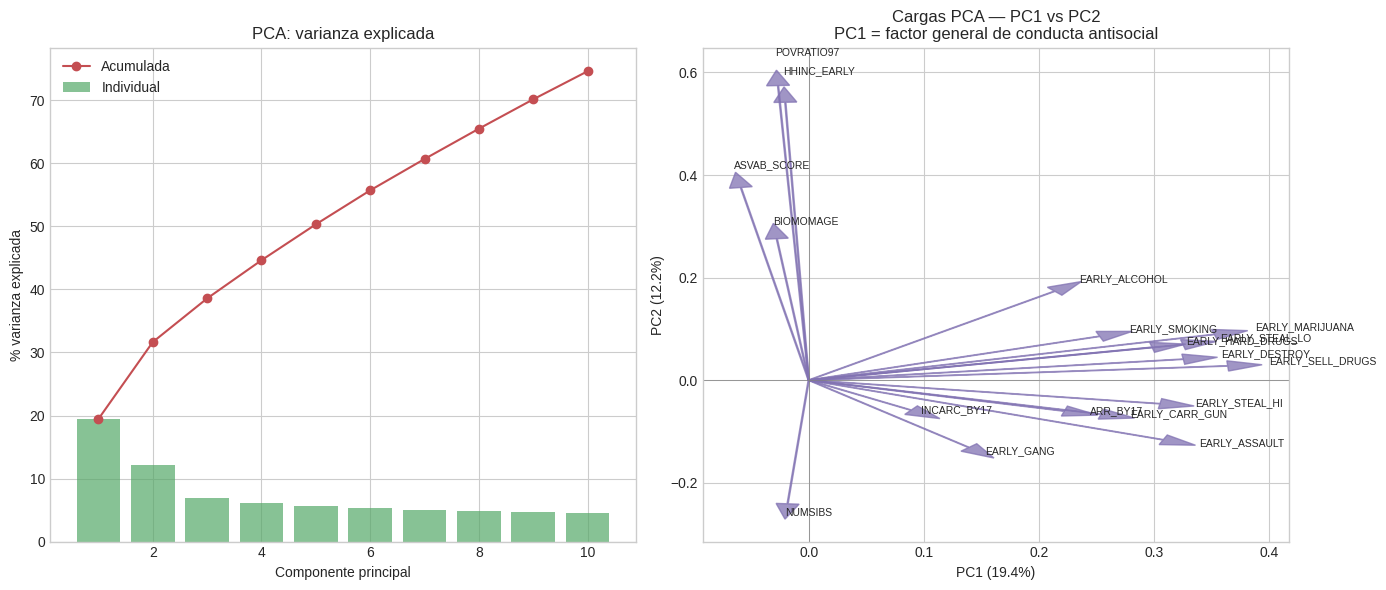

Correlación de cada PC con ASSAULT_18_23:
  PC1: r = +0.301
  PC2: r = -0.086
  PC3: r = -0.023
  PC4: r = +0.103


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scree plot
k = 10
ax1.bar(range(1, k+1), evr[:k]*100, color="#55a868", alpha=0.7, label="Individual")
ax1.plot(range(1, k+1), np.cumsum(evr[:k])*100, marker="o", color="#c44e52", label="Acumulada")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("% varianza explicada")
ax1.set_title("PCA: varianza explicada")
ax1.legend()

# Biplot cargas PC1 vs PC2
for i, v in enumerate(pca_vars):
    ax2.arrow(0, 0, pca.components_[0, i], pca.components_[1, i],
              head_width=0.02, color="#8172b2", alpha=0.75)
    ax2.text(pca.components_[0, i]*1.10, pca.components_[1, i]*1.10, v, fontsize=7.5)
ax2.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax2.set_title("Cargas PCA — PC1 vs PC2\n"
              "PC1 = factor general de conducta antisocial")
ax2.axhline(0, color="gray", lw=0.5)
ax2.axvline(0, color="gray", lw=0.5)

fig.tight_layout()
plt.show()

# Correlación de PCs con el target
print("Correlación de cada PC con ASSAULT_18_23:")
for i in range(4):
    r = np.corrcoef(scores_pca[:, i], y1)[0, 1]
    print(f"  PC{i+1}: r = {r:+.3f}")

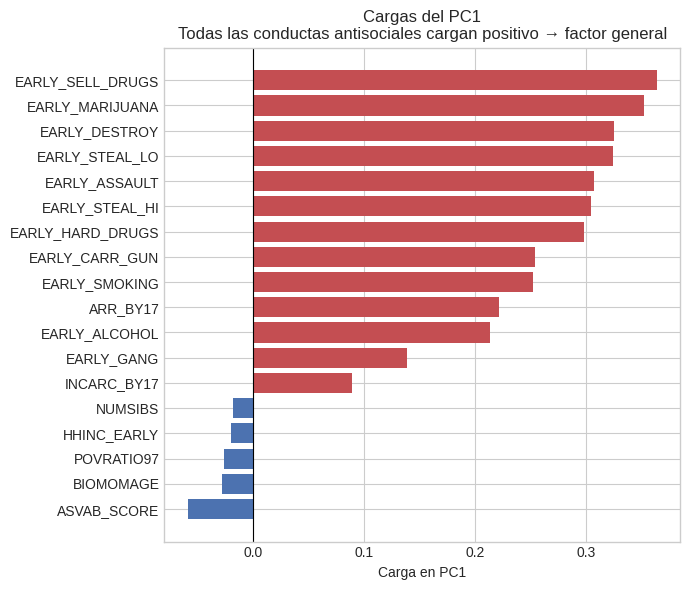

In [20]:
# Cargas del PC1 (de mayor a menor)
load_df = pd.DataFrame(
    pca.components_[:2].T, index=pca_vars, columns=["PC1", "PC2"]
).sort_values("PC1", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
colors_pc1 = ["#c44e52" if v > 0 else "#4c72b0" for v in load_df["PC1"]]
ax.barh(load_df.index[::-1], load_df["PC1"][::-1], color=colors_pc1[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Carga en PC1")
ax.set_title("Cargas del PC1\n"
             "Todas las conductas antisociales cargan positivo → factor general")
fig.tight_layout()
plt.show()

---
## 7. Modelos 2 y 3 — Inicio y Persistencia

Dividimos la muestra según si la persona reportó agresión durante la adolescencia:

| Modelo | Submuestra | Pregunta |
|---|---|---|
| **Inicio** | `EARLY_ASSAULT == 0` | ¿Qué predice que alguien *empiece* a agredir en la adultez? |
| **Persistencia** | `EARLY_ASSAULT == 1` | ¿Qué predice que alguien *siga* agrediendo en la adultez? |

En ambos modelos, `EARLY_ASSAULT` se **excluye** de los predictores porque ya se usa para definir a qué grupo pertenece cada persona.

In [21]:
# Preparar muestra completa con EARLY_ASSAULT
ds2m = ds1[ds1[ecols("ASSAULT_CY", LATE, ds1)].notna().any(axis=1)].copy()
ds2m["ASSAULT_18_23"] = ever(ds2m, ecols("ASSAULT_CY", LATE, ds2m))
ds2m = ds2m[ds2m["ASSAULT_18_23"].notna()].copy()
ds2m["EARLY_ASSAULT"] = ever(ds2m, ecols("ASSAULT_CY", EARLY, ds2m))
ds2m = ds2m[ds2m["EARLY_ASSAULT"].notna()].copy()

# Features sin EARLY_ASSAULT
X_all = pd.DataFrame(index=ds2m.index)
X_all["EARLY_DESTROY"]    = ever(ds2m, ecols("DESTROY_CY",      EARLY, ds2m))
X_all["EARLY_STEAL_LO"]   = ever(ds2m, ecols("STEAL_UNDER_50_CY", EARLY, ds2m))
X_all["EARLY_STEAL_HI"]   = ever(ds2m, ecols("STEAL_OVER_50_CY",  EARLY, ds2m))
X_all["EARLY_SELL_DRUGS"] = ever(ds2m, ecols("SELL_DRUGS_CY",   EARLY, ds2m))
X_all["EARLY_CARR_GUN"]   = ever(ds2m, ecols("CARR_GUN_CY",     EARLY, ds2m))
X_all["EARLY_GANG"]       = ever(ds2m, ecols("GANGS_CY",        EARLY, ds2m))
X_all["EARLY_ALCOHOL"]    = ever(ds2m, ecols("ALCOHOL_CY",      EARLY, ds2m))
X_all["EARLY_MARIJUANA"]  = ever(ds2m, ecols("MARIJUANA_CY",    EARLY, ds2m))
X_all["EARLY_HARD_DRUGS"] = ever(ds2m, ecols("HARD_DRUGS_CY",   EARLY, ds2m))
X_all["EARLY_SMOKING"]    = ever(ds2m, ecols("SMOKING_CY",      EARLY, ds2m))
X_all["ARR_BY17"]         = (ds2m["EVER_ARR_CY17"] > 0).astype(float)
X_all["INCARC_BY17"]      = (ds2m["EVER_INCARC_CY17"] > 0).astype(float)
X_all["HHINC_EARLY"]      = mean_pos(ds2m, ecols("HHINC_CY", EARLY, ds2m))
X_all["ASVAB_SCORE"]      = ds2m["ASVAB_SCORE"]
X_all["POVRATIO97"]       = ds2m["POVRATIO97"]
X_all["NUMSIBS"]          = ds2m["NUMSIBS"]
X_all["BIOMOMAGE"]        = ds2m["BIOMOMAGE"]
X_all["SEX"]              = ds2m["SEX"]
X_all["RACE_ETHNICITY"]   = ds2m["RACE_ETHNICITY"]
X_all["FMSTRC97"]         = ds2m["FMSTRC97"]
X_all["RESPARED"]         = ds2m["RESPARED"]
X_all["MOMEMP97"]         = ds2m["MOMEMP97"]
X_all["DADEMP97"]         = ds2m["DADEMP97"]

feat_ip = list(X_all.columns)
imp_ip  = SimpleImputer(strategy="median")
Xi_all  = pd.DataFrame(imp_ip.fit_transform(X_all), columns=feat_ip, index=X_all.index)
y_all   = ds2m["ASSAULT_18_23"].astype(int)
early   = ds2m["EARLY_ASSAULT"].astype(int)

n_inicio = (early == 0).sum()
n_pers   = (early == 1).sum()
print(f"Total: {len(y_all):,}")
print(f"Inicio (sin agresión temprana):      {n_inicio:,} | "
      f"prevalencia={y_all[early==0].mean()*100:.1f}%")
print(f"Persistencia (con agresión temprana): {n_pers:,} | "
      f"prevalencia={y_all[early==1].mean()*100:.1f}%")

Total: 8,597
Inicio (sin agresión temprana):      6,568 | prevalencia=10.6%
Persistencia (con agresión temprana): 2,029 | prevalencia=37.4%


In [22]:
def run_model(mask, nombre, color):
    """Entrena RF en la submuestra, devuelve (rf, gini, perm_s, auc_test, cv_scores)."""
    Xm, ym = Xi_all[mask], y_all[mask]
    Xtr, Xte, ytr, yte = train_test_split(
        Xm, ym, test_size=0.25, random_state=42, stratify=ym
    )
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=9, min_samples_leaf=20,
        max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf.fit(Xtr, ytr)
    prob   = rf.predict_proba(Xte)[:, 1]
    auc    = roc_auc_score(yte, prob)
    cv     = cross_val_score(rf, Xm, ym, cv=5, scoring="roc_auc", n_jobs=-1)
    gini   = pd.Series(rf.feature_importances_, index=feat_ip).sort_values(ascending=False)
    perm   = permutation_importance(rf, Xte, yte, n_repeats=30, random_state=42,
                                    scoring="roc_auc", n_jobs=-1)
    perm_s = pd.Series(perm.importances_mean, index=feat_ip).sort_values(ascending=False)
    print(f"\n{nombre}")
    print(f"  n={len(ym):,} | prevalencia={ym.mean()*100:.1f}%")
    print(f"  AUC test={auc:.4f} | AUC CV={cv.mean():.4f} ± {cv.std():.4f}")
    return rf, gini, perm_s, auc, cv, prob, yte

rf2, gini2, perm2, auc2, cv2, prob2, yte2 = run_model(early == 0, "Modelo 2 — Inicio", "#dd8452")
rf3, gini3, perm3, auc3, cv3, prob3, yte3 = run_model(early == 1, "Modelo 3 — Persistencia", "#c44e52")


Modelo 2 — Inicio
  n=6,568 | prevalencia=10.6%
  AUC test=0.7098 | AUC CV=0.6980 ± 0.0394

Modelo 3 — Persistencia
  n=2,029 | prevalencia=37.4%
  AUC test=0.5840 | AUC CV=0.6171 ± 0.0366


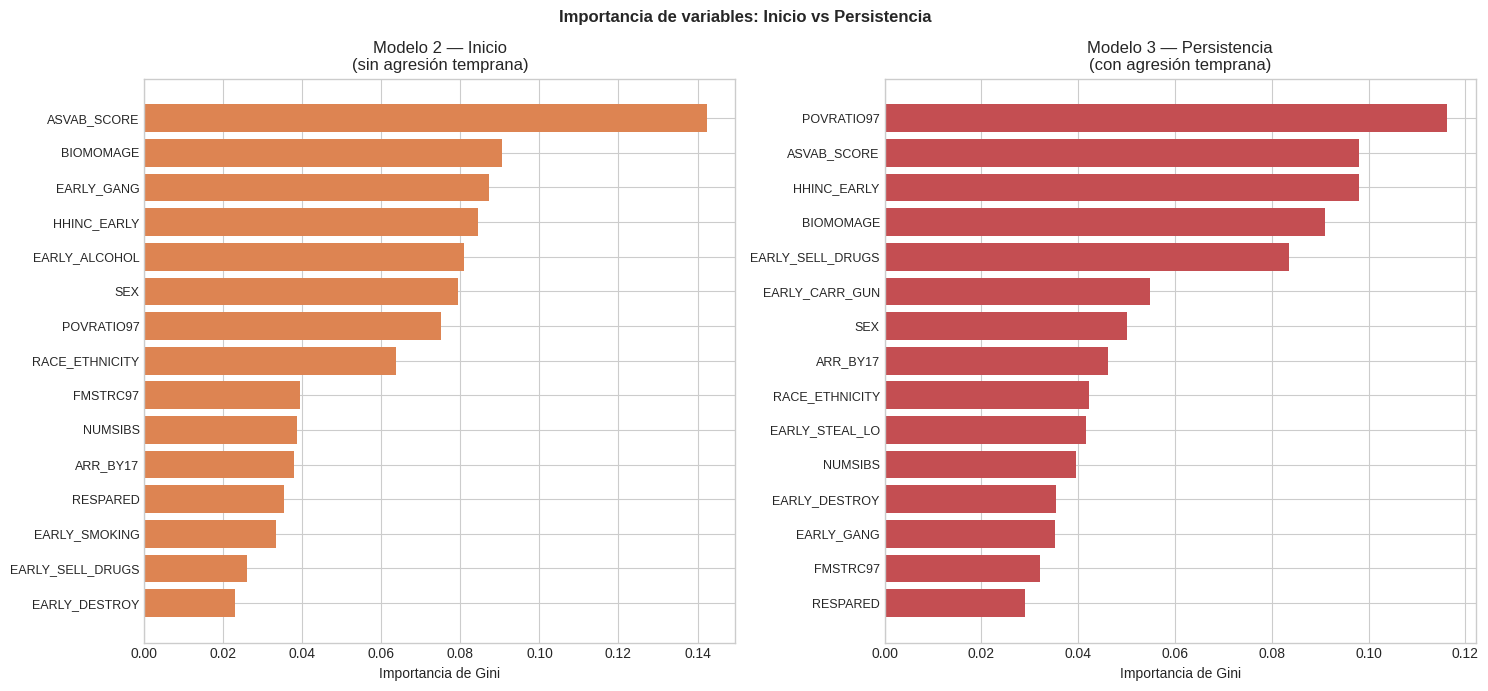

In [23]:
# Importancia Gini — Modelos 2 y 3 lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, gini, titulo, color in [
    (axes[0], gini2, "Modelo 2 — Inicio\n(sin agresión temprana)", "#dd8452"),
    (axes[1], gini3, "Modelo 3 — Persistencia\n(con agresión temprana)", "#c44e52")
]:
    g = gini.head(15)[::-1]
    ax.barh(range(len(g)), g.values, color=color)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels(g.index, fontsize=9)
    ax.set_xlabel("Importancia de Gini")
    ax.set_title(titulo)

fig.suptitle("Importancia de variables: Inicio vs Persistencia", fontweight="bold")
fig.tight_layout()
plt.show()

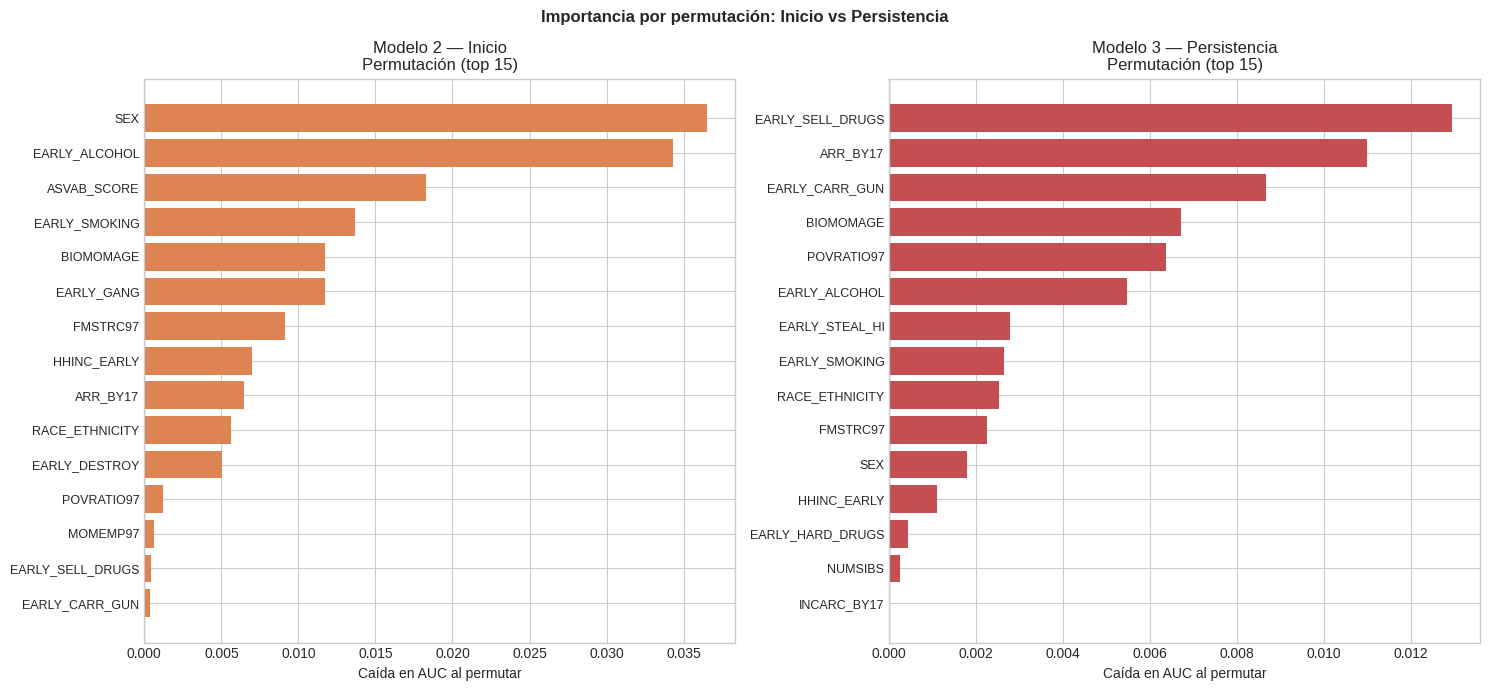


Top-5 por permutación — Inicio:
  SEX                    +0.03651
  EARLY_ALCOHOL          +0.03429
  ASVAB_SCORE            +0.01827
  EARLY_SMOKING          +0.01368
  BIOMOMAGE              +0.01174

Top-5 por permutación — Persistencia:
  EARLY_SELL_DRUGS       +0.01293
  ARR_BY17               +0.01098
  EARLY_CARR_GUN         +0.00865
  BIOMOMAGE              +0.00670
  POVRATIO97             +0.00637


In [24]:
# Importancia por permutación — Modelos 2 y 3
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, perm, titulo, color in [
    (axes[0], perm2, "Modelo 2 — Inicio\nPermutación (top 15)", "#dd8452"),
    (axes[1], perm3, "Modelo 3 — Persistencia\nPermutación (top 15)", "#c44e52")
]:
    p = perm.head(15)[::-1]
    ax.barh(range(len(p)), p.values, color=color)
    ax.set_yticks(range(len(p)))
    ax.set_yticklabels(p.index, fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Caída en AUC al permutar")
    ax.set_title(titulo)

fig.suptitle("Importancia por permutación: Inicio vs Persistencia", fontweight="bold")
fig.tight_layout()
plt.show()

print("\nTop-5 por permutación — Inicio:")
for k, v in perm2.head(5).items():
    print(f"  {k:22s} {v:+.5f}")

print("\nTop-5 por permutación — Persistencia:")
for k, v in perm3.head(5).items():
    print(f"  {k:22s} {v:+.5f}")

---
## 8. Comparación final de los tres modelos

El resultado más importante del análisis está en la **comparación entre modelos**. El modelo global funciona bien porque aprovecha la señal de agresión temprana. Al separar la muestra, vemos que:
- El **inicio** se puede predecir razonablemente (AUC ≈ 0.71) con variables de contexto
- La **persistencia** es mucho más difícil de anticipar (AUC ≈ 0.58, casi al azar)

Esto tiene implicaciones de política pública: parece más útil invertir en prevención temprana que intentar clasificar con precisión quién seguirá siendo violento después de un primer episodio.

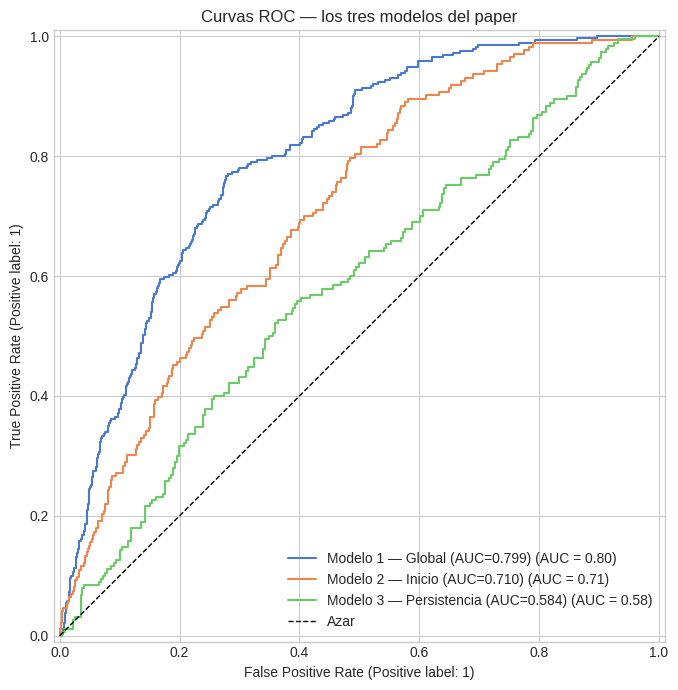

In [25]:
# Curvas ROC de los tres modelos juntas
fig, ax = plt.subplots(figsize=(7, 7))

RocCurveDisplay.from_predictions(
    y1_te, y1_prob, ax=ax,
    name=f"Modelo 1 — Global (AUC={auc1:.3f})"
)
RocCurveDisplay.from_predictions(
    yte2, prob2, ax=ax,
    name=f"Modelo 2 — Inicio (AUC={auc2:.3f})"
)
RocCurveDisplay.from_predictions(
    yte3, prob3, ax=ax,
    name=f"Modelo 3 — Persistencia (AUC={auc3:.3f})"
)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
ax.set_title("Curvas ROC — los tres modelos del paper")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
# Tabla comparativa de desempeño
resumen = pd.DataFrame([
    {
        "Modelo": "1 — Global",
        "Muestra": len(y1),
        "Prevalencia (%)": round(y1.mean()*100, 1),
        "AUC test": round(auc1, 4),
        "AUC CV (media)": round(cv1.mean(), 4),
        "AUC CV (std)": round(cv1.std(), 4),
    },
    {
        "Modelo": "2 — Inicio",
        "Muestra": (early == 0).sum(),
        "Prevalencia (%)": round(y_all[early==0].mean()*100, 1),
        "AUC test": round(auc2, 4),
        "AUC CV (media)": round(cv2.mean(), 4),
        "AUC CV (std)": round(cv2.std(), 4),
    },
    {
        "Modelo": "3 — Persistencia",
        "Muestra": (early == 1).sum(),
        "Prevalencia (%)": round(y_all[early==1].mean()*100, 1),
        "AUC test": round(auc3, 4),
        "AUC CV (media)": round(cv3.mean(), 4),
        "AUC CV (std)": round(cv3.std(), 4),
    },
])

resumen = resumen.set_index("Modelo")
display(resumen)

,Muestra,Prevalencia (%),AUC test,AUC CV (media),AUC CV (std)
Modelo,,,,,
1 — Global,8609,16.9,0.7987,0.7637,0.0295
2 — Inicio,6568,10.6,0.7098,0.6980,0.0394
3 — Persistencia,2029,37.4,0.5840,0.6171,0.0366


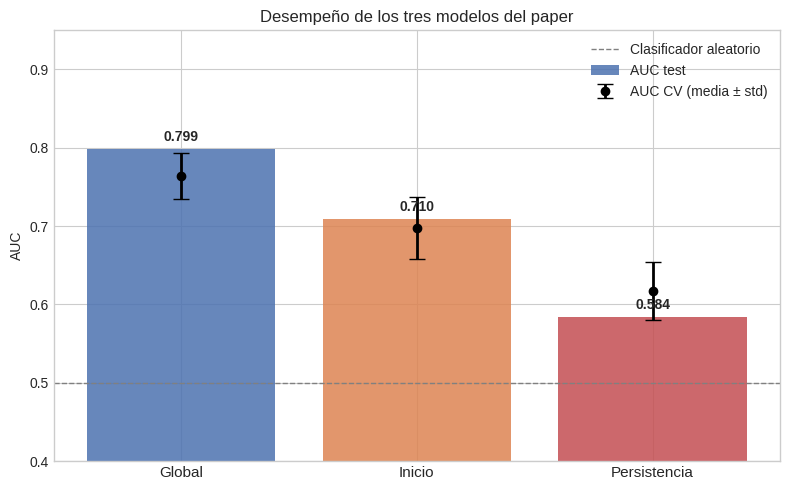

In [27]:
# Comparación visual: AUC de los tres modelos con barras de error (CV)
fig, ax = plt.subplots(figsize=(8, 5))

modelos   = ["Global", "Inicio", "Persistencia"]
auc_vals  = [auc1, auc2, auc3]
cv_medias = [cv1.mean(), cv2.mean(), cv3.mean()]
cv_stds   = [cv1.std(), cv2.std(), cv3.std()]
colores   = ["#4c72b0", "#dd8452", "#c44e52"]

x = np.arange(len(modelos))
bars = ax.bar(x, auc_vals, color=colores, alpha=0.85, label="AUC test")
ax.errorbar(x, cv_medias, yerr=cv_stds, fmt="o", color="black",
            capsize=6, linewidth=2, label="AUC CV (media ± std)")

ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="Clasificador aleatorio")
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel("AUC")
ax.set_ylim(0.4, 0.95)
ax.set_title("Desempeño de los tres modelos del paper")
ax.legend()

for bar, v in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

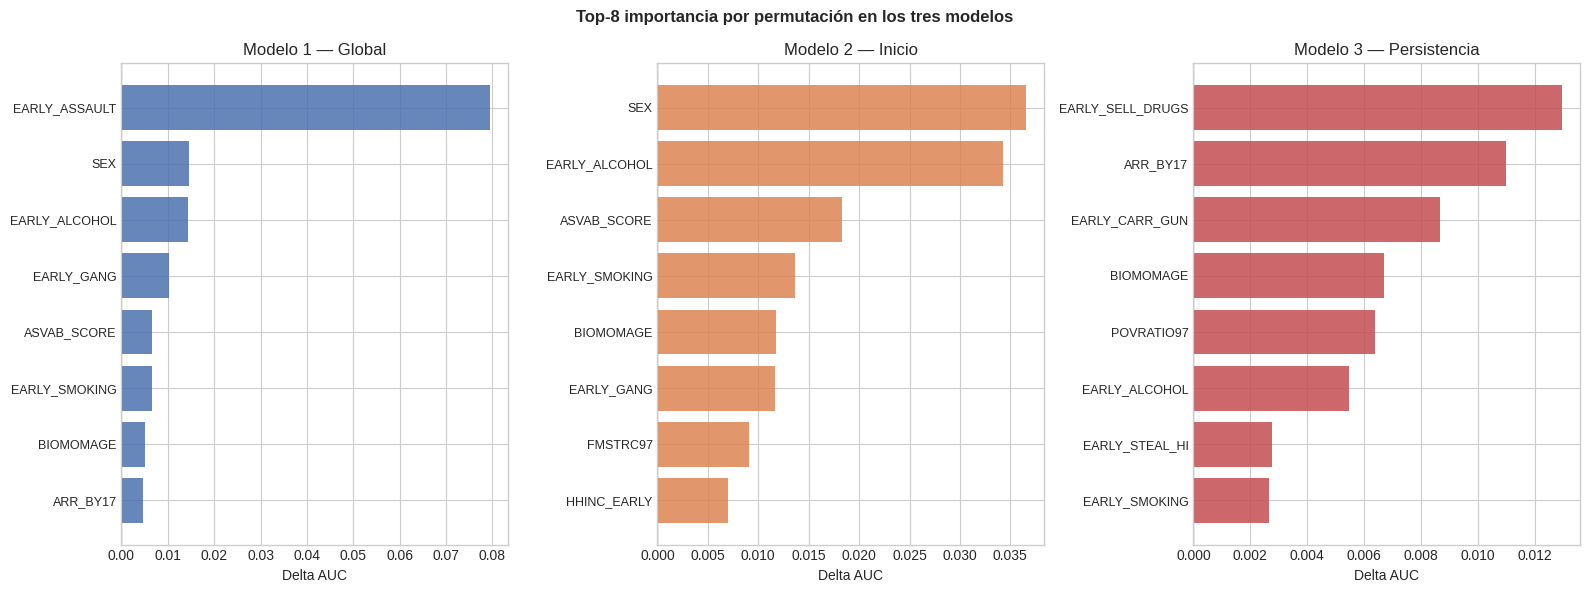


Lectura clave:
- Modelo Global: EARLY_ASSAULT domina; luego sexo y conductas de riesgo.
- Modelo Inicio: sexo y alcohol temprano son las señales más robustas;
  variables de contexto (pandilla, ASVAB) también aparecen.
- Modelo Persistencia: venta de drogas, arrestos y portación de arma lideran;
  el AUC bajo (~0.58) indica que la persistencia es difícil de anticipar.



In [28]:
# Top-5 por permutación en los tres modelos — en un solo panel
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

datos = [
    (perm1_s, "Modelo 1 — Global", "#4c72b0"),
    (perm2,   "Modelo 2 — Inicio", "#dd8452"),
    (perm3,   "Modelo 3 — Persistencia", "#c44e52"),
]

for ax, (perm_s, titulo, color) in zip(axes, datos):
    p = perm_s.head(8)[::-1]
    ax.barh(range(len(p)), p.values, color=color, alpha=0.85)
    ax.set_yticks(range(len(p)))
    ax.set_yticklabels(p.index, fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Delta AUC")
    ax.set_title(titulo)

fig.suptitle("Top-8 importancia por permutación en los tres modelos", fontweight="bold")
fig.tight_layout()
plt.show()

print("""
Lectura clave:
- Modelo Global: EARLY_ASSAULT domina; luego sexo y conductas de riesgo.
- Modelo Inicio: sexo y alcohol temprano son las señales más robustas;
  variables de contexto (pandilla, ASVAB) también aparecen.
- Modelo Persistencia: venta de drogas, arrestos y portación de arma lideran;
  el AUC bajo (~0.58) indica que la persistencia es difícil de anticipar.
""")